<a href="https://colab.research.google.com/github/nikolaicarrion/2026_Intro_Python/blob/main/1.3-numpy-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.3-numpy-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [1]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"gsw": "gsw", "pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import numpy as `np`, and encode units in your variable names.

## Exercise 1: Create and inspect

Build the following 3×4 field of temperatures (°C) as a numpy array:

`5.2 4.8 6.1 3.9 1.3 0.5 -0.8 -1.2 -2.6 -3.1 -1.9 0.2`

Print its `shape`, `ndim`, and `dtype`, and its overall mean rounded to two decimals.
Then create, and print, three arrays of the same shape without typing the shape out by hand:
all ones, a uniform reference field of 15.0 °C, and random values in [0, 1).

In [2]:
import numpy as np
temp_c = np.array([[5.2, 4.8, 6.1, 3.9],
                  [1.3, 0.5, -0.8, -1.2],
                  [-2.6, -3.1, -1.9, 0.2]])

print(temp_c.shape)
print(temp_c.ndim)
print(temp_c.dtype)
print(round(np.mean(temp_c),2))

one = np.ones(4)
unif_ref = np.ones(4) * 15.0
random = np.random.random(4)

matrix = np.array([one,
                  unif_ref,
                  random])

print(matrix)



(3, 4)
2
float64
1.03
[[ 1.          1.          1.          1.        ]
 [15.         15.         15.         15.        ]
 [ 0.73975994  0.15482211  0.2723722   0.4070933 ]]


## Exercise 2: Index and slice

Given

```python
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])
```

print the last row, the first column, and the 2×2 sub-block formed by the first two rows and the last two columns.

Finally, take a slice of the first row, change its first element to `99.0`, and print the original array. Then repeat using `.copy()`. Explain the difference in a comment.

In [3]:
a = np.array([[1.0, 2.0, 3.0, 4.0],
              [5.0, 6.0, 7.0, 8.0],
              [9.0, 10.0, 11.0, 12.0]])

first_row = a[0,:]
print(first_row)

first_column = a[:,0]
print(first_column)

subblock = a[0:2,2:4]
print(subblock)

first_row_sub = subblock[0,:]
first_row_sub[0] = 99

[1. 2. 3. 4.]
[1. 5. 9.]
[[3. 4.]
 [7. 8.]]


## Exercise 3: Masking and np.where

Given

```python
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])
```

print the values that exceed 10 °C, their mean, and the percentage of the field they make up.
Then build a clipped field in which every value below 0 °C is set to 0, using `np.where`.

In [4]:
temp_celsius = np.array([[-1.0, 12.0,  3.0],
                         [ 8.0, -2.0, 15.0],
                         [ 4.0,  0.5, 11.0]])

thresh = np.where(temp_celsius > 10, 1, 0)
print(thresh)

intermed_df = temp_celsius * thresh
print(intermed_df)

print(round(np.mean(intermed_df),2))

bool_matrix = thresh > 0.0
n = int(bool_matrix.sum())

m = temp_celsius.size
print(round(n/m * 100,2))

thresh_2 = np.where(temp_celsius < 0, 0, 1)
intermed_df2 = temp_celsius * thresh_2
print(intermed_df2)



[[0 1 0]
 [0 0 1]
 [0 0 1]]
[[-0. 12.  0.]
 [ 0. -0. 15.]
 [ 0.  0. 11.]]
4.22
33.33
[[-0.  12.   3. ]
 [ 8.  -0.  15. ]
 [ 4.   0.5 11. ]]


## Exercise 4: Broadcasting and grids

Given the field below, add a per-column offset (length 4) to every row, and separately add a per-row offset (length 3) to every column.

```python
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])
```

Then build a grid of 4 evenly spaced longitudes from 6 to 9 °E and 3 evenly spaced latitudes
from 46 to 47 °N, so that it has the same shape as `field`. On that grid, compute a synthetic temperature
field that is 15.0 °C at (6 °E, 46 °N), cools by 0.6 °C per degree of latitude northward, and warms
by 0.2 °C per degree of longitude eastward. Compute it twice, once from the 2D arrays that
`np.meshgrid` returns and once by broadcasting the 1D latitudes and longitudes directly, and
confirm with `np.allclose` that the two agree.

In [5]:
field = np.array([[1.0, 2.0, 3.0, 4.0],
                  [5.0, 6.0, 7.0, 8.0],
                  [9.0, 10.0, 11.0, 12.0]])
col_offset = np.array([0.0, 1.0, 2.0, 3.0])
row_offset = np.array([10.0, 20.0, 30.0])

print(row_offset[:,None].shape)

print(field + col_offset)
print(field + row_offset[:,None])

# Grid

longitude = np.linspace(6,9,4)
print(longitude)

latitude = np.linspace(46,47,3)
print(latitude)



(3, 1)
[[ 1.  3.  5.  7.]
 [ 5.  7.  9. 11.]
 [ 9. 11. 13. 15.]]
[[11. 12. 13. 14.]
 [25. 26. 27. 28.]
 [39. 40. 41. 42.]]
[6. 7. 8. 9.]
[46.  46.5 47. ]


## Exercise 5: Axis reductions

Given seasonal mean temperatures at three stations, one row per station and one column per season
(winter, spring, summer, autumn):

```python
seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])
```

print the annual mean at each station and the index of each station's warmest season. Then find the
coldest value in each season twice, once with the method and once with the numpy function, and
confirm they agree.

Finally, given four days of rainfall at two stations, one row per station,

```python
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])
```

use `cumsum` along the right axis to get the rain to date. Print the index of the station that was
wetter after the second day and the index of the station that was wetter after all four. Are they
the same station?

In [6]:
# Annual mean at each station

seasonal_celsius = np.array([[ 2.1,  9.8, 18.4, 10.2],
                             [-1.5,  7.2, 16.9,  8.0],
                             [ 4.0, 11.5, 20.3, 12.6]])

station1 = np.mean(seasonal_celsius[0,:])
print(station1)

station2 = np.mean(seasonal_celsius[1,:])
print(station2)

station3 = np.mean(seasonal_celsius[2,:])
print(station3)

# Index of each station's warmest season

warmest = np.argmax(seasonal_celsius, axis = 1)
print(warmest)


#Coldest value in season

coldest_numpy = np.min(seasonal_celsius, axis = 0)
coldest = np.where(seasonal_celsius)

# Coldest value in each season (down the rows, axis=0), done two ways
coldest_method = seasonal_celsius.min(axis=0)      # ndarray method
coldest_func   = np.min(seasonal_celsius, axis=0)  # numpy function
print("Coldest per season (method):  ", coldest_method)
print("Coldest per season (function):", coldest_func)

# Confirm they agree
print("Agree:", np.array_equal(coldest_method, coldest_func))

# Rain
rain_mm = np.array([[0.0, 6.2, 1.1, 0.0],
                    [2.4, 0.0, 0.0, 8.3]])

wettes_day2 = np.argmax(np.cumsum(rain_mm, axis=1)[:, 1])
print(wettes_day2) #station 1 had the highest cumulative rainfall after day 2

wettest_day4 = np.argmax(np.cumsum(rain_mm, axis=1)[:,-1])
print(wettest_day4)

10.125
7.6499999999999995
12.1
[2 2 2]
Coldest per season (method):   [-1.5  7.2 16.9  8. ]
Coldest per season (function): [-1.5  7.2 16.9  8. ]
Agree: True
0
1


## Exercise 6: Missing data and interpolation

Given hourly air temperatures with a gap of two readings,

```python
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])
```

fill the gap by linear interpolation against the integer index. Then print the NaN-aware mean of the
original series and the ordinary mean of the filled one. The two differ; say in a comment why.

In [7]:
temp_celsius = np.array([12.0, 13.5, np.nan, np.nan, 18.0, 18.5])

temp_celsius_interp = temp_celsius.copy()

print(temp_celsius_interp)

nan_mask = np.isnan(temp_celsius)
y = np.arange(len(temp_celsius))

print(nan_mask)

temp_celsius_interp[nan_mask] = np.interp(
    y[nan_mask],          # positions where temperature is missing
    y[~nan_mask],         # positions where temperature is known
    temp_celsius[~nan_mask]  # known temperatures
)

print(temp_celsius_interp)

mean_nan = np.mean(temp_celsius)
mean = np.mean(temp_celsius_interp)

print(mean_nan == mean)

[12.  13.5  nan  nan 18.  18.5]
[False False  True  True False False]
[12.  13.5 15.  16.5 18.  18.5]
False


## Exercise 7: Avoid the dtype trap

An assistant wrote this function to compute each cell's share of the total rainfall in an integer
field of rain-gauge readings:

```python
def rain_share(rain_mm):
    share = np.zeros_like(rain_mm)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
```

Call it and print the result. Explain in a comment why every share is 0, then fix the function
twice: once keeping the preallocation but passing `dtype=float` to `np.zeros_like`, and once
without preallocating at all. Confirm that each fixed version returns a float array whose shares
sum to 1.

In [8]:

def rain_share(rain_mm):
    share = np.zeros_like(rain_mm) #dtype interger array
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])

test1 = rain_share(rain_mm)
print(test1.dtype)


def rain_share(rain_mm):
    share = np.zeros_like(rain_mm, dtype=float)
    share[:] = rain_mm / rain_mm.sum()
    return share

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])
test2 = rain_share(rain_mm)
print(test2.dtype)

def rain_share(rain_mm):
    return rain_mm / rain_mm.sum()

rain_mm = np.array([[0, 2, 5], [1, 0, 8], [3, 4, 2]])

test3 = rain_share(rain_mm)
print(test3.dtype)

int64
float64
float64


## Exercise 8: Reshape and stack

1. Create the integers 0 to 11 as a 1D array, then reshape it into a 3×4 array and print both
   shapes.
2. Reshape the same data into a 4×3 array. Print it and say in a comment why the numbers appear
   in a different arrangement.
3. Use `reshape(-1)` to flatten your 3×4 array back to 1D, and confirm the shape.
4. Stack the 3×4 array on top of a row of zeros with `np.vstack`, and print the resulting shape.

In [9]:
data = np.arange(0,12)
print(data.dtype)
print(data)

data_reshape = data.reshape(3, 4)
print(data_reshape)

data_reshape2 = data.reshape(4,3)
print(data_reshape2)

data_flatten = data_reshape.reshape(-1)
print(data_flatten)

zeros = np.zeros(data_reshape2.shape[1])
print(zeros)

stack = np.vstack([zeros, data_reshape2])
print(stack)

int64
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[0. 0. 0.]
[[ 0.  0.  0.]
 [ 0.  1.  2.]
 [ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]]


## Exercise 9: Ocean float profiles

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/argo-float-cycle.png" alt="A diagram of one Argo float cycle, numbered one to seven, from deployment through drift, dive, ascent and satellite transmission" width="100%">

<em>One cycle of an Argo float: deployment, descent to a drifting depth of about 1000 m, ten days of
drift, a dive to the profiling depth, then the ascent during which the measurements are taken, and
transmission to satellite at the surface before the next cycle begins. The panel on the right shows
what one ascent produces — the temperature and salinity profiles you are about to work with.
Illustration &copy; Thomas Haessig, from
<a href="https://www.euro-argo.eu/Outreach/Educational-material/Discover-Argo-floats-for-kids/How-do-the-Argo-floats-fulfill-their-mission-in-the-Ocean">Euro-Argo ERIC's educational material</a>.</em>


[Argo](https://argo.ucsd.edu/) floats are autonomous instruments that drift with ocean currents,
periodically diving and surfacing while recording temperature, salinity, and pressure. Each dive
produces one *profile*: a set of measurements at many depth *levels*, with a single latitude,
longitude, and date attached.

This exercise uses real Argo data. Steps 1 to 8 use only what 1.1 to 1.3 cover: loading
arrays, inspecting shapes, rebuilding an axis, vectorised arithmetic, reductions along an axis,
boolean masks, and NaN-aware statistics. Steps 9 to 11 then plot what you computed.

**ℹ️ Beyond this subchapter**

Steps 9 to 11 use `matplotlib`, which gets its own treatment in 1.4. Import it once with
`import matplotlib.pyplot as plt`; after that you need only the functions below, and each is
named again where it is wanted:

- `plt.figure()` — start a new, empty figure; without it, every plot in a cell lands on the
  same axes
- [`plt.plot`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) — a line, or
  one line per column when handed a 2D array
- [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) — a
  line with error bars
- [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) — points
- `plt.xlabel`, `plt.ylabel`, `plt.title` — each takes a string
- `plt.show()` — draw the current figure

An array of numbers with no picture attached is hard to sanity-check, which is why these three
steps sit here rather than waiting for 1.4: the profiles are the fastest way to see whether Steps 4
to 6 produced something physical.

In [10]:
# Pre-supplied: download and unzip the Argo data files.
import pooch

files = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/argo_float_data.zip",
    known_hash="sha256:dd913ba3450241bcd5d5697187ea68d398bdd7fd563a04cc74386834749c25f5",
    processor=pooch.Unzip(),
    path=pooch.os_cache("mlees"),
)
for f in sorted(files):
    print(f)

Unzipping contents of '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip' to '/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip'


/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/P.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/S.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/T.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/date.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lat.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/levels.npy
/root/.cache/mlees/3447957d2e428811e6534de5c131c0db-argo_float_data.zip.unzip/lon.npy


**Step 1.** Load each `.npy` file into a numpy array with `np.load`. Name them `T` (temperature,
°C), `S` (practical salinity, unitless), `P` (pressure, dbar), `date`, `lat`, `lon`, and `level` (depth level).

Read the filenames printed above to work out which file is which.

In [11]:
# Your solution here
# Hint: every file sits in the same folder, Path(files[0]).parent (Path comes from pathlib)
# Hint: join a filename onto that folder with /, as in Path("_files") / "station_daily.csv"
# Hint: np.load(path) returns the array stored in a .npy file

from pathlib import Path

data_path = Path(files[0]).parent

P = np.load(data_path / "P.npy")
S = np.load(data_path / "S.npy")
T = np.load(data_path / "T.npy")
date = np.load(data_path / "date.npy")
lat = np.load(data_path / "lat.npy")
lon = np.load(data_path / "lon.npy")
level = np.load(data_path / "levels.npy")

**Step 2.** Print the `shape` of every array you loaded. Then answer in a comment: which
dimension do `T`, `S`, and `P` share with `level`, and which do they share with `lat`, `lon`,
and `date`?

In [12]:
# Your solution here
# Hint: the profile arrays are two-dimensional; the coordinate arrays are one-dimensional
# Hint: a 2D array's shape tells you the length of each axis — match those against the 1D shapes

print(P.shape)
print(S.shape)
print(T.shape)
print(date.shape)
print(lat.shape)
print(lon.shape)
print(level.shape)

(78, 75)
(78, 75)
(78, 75)
(75,)
(75,)
(75,)
(78,)


**Step 3.** The `level` array is a regular sequence. Recreate it twice — once with `np.arange`
and once with `np.linspace` — and confirm each matches the original using `np.allclose`.

Read `level[0]`, `level[-1]`, and `level.size` first to work out the arguments.

In [35]:
# Your solution here
# Hint: np.arange(start, stop, step) excludes the stop value
# Hint: np.linspace(start, stop, num) includes both ends
# Hint: np.allclose(a, b) returns True when every pair of elements is close enough

print(level[0])
print(level[-1])
print(level.size)

range = np.arange(0,78,1)
print(range)

linspace = np.linspace(0,77,78)
print(linspace)

print(np.allclose(range,linspace))

0
77
78
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77.]
True


**Step 4.** Compute the density of seawater relative to pure water, in kg m⁻³:

$$\rho - \rho_{\text{pure water}} = a\,S + b\,\Theta + c\,\Theta^{2}$$

where $S$ is salinity and $\Theta$ is the *conservative* temperature, computed from
temperature, salinity, and pressure by the `gsw` library. The constants are

```python
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
```

The cell below imports the function. Compute `conservative_temp` and `relative_density`, print
the shape of your result, and check it matches `T`.

Both `CT_from_t` and the formula expect *absolute* salinity, in g/kg, while Argo reports
*practical* salinity, which has no unit. Absolute salinity is about 0.5 % larger; for these
profiles, using practical salinity in its place lowers every relative density by about
0.13 kg m⁻³, which is small enough to ignore here. `gsw.SA_from_SP` does the exact conversion
when it matters.

Source: Roquet et al. (2015), *J. Phys. Oceanogr.* 45, 2564–2579, and the
[TEOS-10 GSW toolbox](https://www.teos-10.org/).

In [36]:
# Pre-supplied: the conservative-temperature function from the gsw library
from gsw import CT_from_t

In [42]:
# Your solution here
# Hint: CT_from_t(SA, t, p) takes salinity, temperature, and pressure — in that order
# Hint: the whole formula is one vectorised expression; no loop is needed
# Hint: Theta**2 squares every element

a = 7.718e-1
b = -8.44e-2
c = -4.561e-3
conservative_temp = CT_from_t(S, T, P)

relative_density = a * S + b*conservative_temp + c * conservative_temp**2
print(relative_density)

[[24.26878778 24.30901623 24.18510597 ... 24.37483439 23.60704513
  23.98828331]
 [24.32477667 24.32400413 24.19045883 ... 24.53101768 24.09992029
  23.98930505]
 [24.45644758 24.33382758 24.19427794 ... 24.58041622 24.21339484
  24.000865  ]
 ...
 [26.58088425 26.58466521 26.58605858 ... 26.59390729 26.5980916
  26.59702996]
 [26.58479005 26.58939524 26.59027359 ... 26.59905835 26.60307089
  26.60154496]
 [26.58919785 26.59362837 26.59605156 ...         nan 26.60731704
          nan]]


**Step 5.** Compute the mean and the standard deviation of `T`, `S`, `P`, and
`relative_density` **at each depth**, averaging across all the profiles.

Check your result has the same shape as `level` — if it does not, you reduced along the wrong
axis.

In [57]:
# Your solution here
# Hint: pick the axis that runs across profiles, not across depths
# Hint: mean_T.shape should equal level.shape

print(T.shape)
print(level.shape)

mean_T = np.mean(T, axis=1)
std_T = np.std(T, axis=1)

mean_S = np.mean(S, axis=1)
std_S = np.std(S, axis=1)

mean_P = np.mean(P, axis=1)
std_P = np.std(P, axis=1)

mean_rd = np.mean(relative_density, axis=1)
std_rd = np.std(relative_density, axis=1)



(78, 75)
(78,)
[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan 10.80430666 10.49702667
 10.1749066   9.83453334  9.48625332  9.19793334  8.66010666  8.12324001
  7.60221333  7.15289333  6.74250667  6.39543999  6.04598667  5.74538665
  5.48913333  5.26604001  5.08768     4.93479998  4.77769334  4.65368
  4.54237334  4.44274664  4.35933333         nan         nan         nan
         nan         nan         nan         nan         nan         nan]


**Step 6.** Look at the mean you just computed. Many entries are `nan`, because Argo profiles
contain missing values and an ordinary mean propagates them.

1. Count how many values in `T` are missing, using `np.isnan` and a sum over the boolean mask.
2. Express that as a percentage of all values in `T`.
3. Recompute the mean and standard deviation with `np.nanmean` and `np.nanstd`, and confirm no
   `nan` remains.

In [94]:
# Your solution here
# Hint: np.isnan(T) gives a boolean array; True counts as 1 when summed
# Hint: T.size is the total number of elements
# Hint: np.isnan(result).sum() counts the nan that survived; it should be 0

# 1

result = np.isnan(T).sum()
print(result)

# 2
prct = (result / T.size) * 100
print(round(prct,2))

# 3

nanmean_T = np.nanmean(T, axis=1)
nanstd_T = np.nanstd(T, axis=1)

print(np.isnan(nanmean_T).sum())
print(np.isnan(nanstd_T).sum())

101
1.73
0
0
78


**Step 7.** Using `np.where`, build an array that labels each depth `"warm"` where the mean
temperature there is above 10 °C and `"cold"` otherwise. Print the first ten labels alongside
the first ten depths.

Then, using a boolean mask, print the depths at which the mean temperature is below 5 °C.

In [97]:
# Your solution here
# Hint: np.where(condition, value_if_true, value_if_false) works element-wise
# Hint: level[mask] selects the depths where the mask is True

depth_label = np.where(nanmean_T > 10, "warm", "cold")
print(depth_label)

mask = level[nanmean_T < 5]
print(mask)

['warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm'
 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm'
 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm'
 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm'
 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'warm' 'cold'
 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold'
 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold'
 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold' 'cold']
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77]


**Step 8.** Assemble a summary array with `np.vstack`: one row of depths, one of mean
temperature, one of mean salinity, and one of mean relative density — four rows in total.

Print its shape, save it to `_files/argo_summary.npy`, load it back, and confirm with `np.allclose`
that the round trip changed nothing.

In [106]:
# Your solution here
# Hint: np.vstack takes a list of 1D arrays and stacks them as rows
# Hint: your summary should have shape (4, n_levels)
# Hint: _files/ may not exist yet; create it first with Path("_files").mkdir(exist_ok=True)


from pathlib import Path
Path("_files").mkdir(exist_ok=True)      # _files/ is not committed, so create it first

nanmean_rd = np.nanmean(relative_density, axis=1)

summary = np.vstack((
    level,
    nanmean_T,
    nanstd_T,
    nanmean_rd
))

print(summary.shape)

np.save("_files/summary.npy", summary)

(4, 78)


**Step 9.** Plot each of `T`, `S`, `P` and `relative_density` against depth — four figures, one
per variable.

Each array is `(level, profile)`, so handing the whole array to `plt.plot` draws one line per
profile. Put the variable on the *x*-axis and `level` on the *y*-axis, which is the oceanographic
convention: depth runs down the page, and a profile is read the way the float measured it.

It will look messy, because 75 profiles are drawn on top of each other.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-profiles.png" alt="Many overlapping salinity profiles plotted against depth level, forming a dense band that shifts towards fresher water with depth" width="500">

<em>The salinity panel, as a check on yours. Label the axes and give each figure a title.</em>

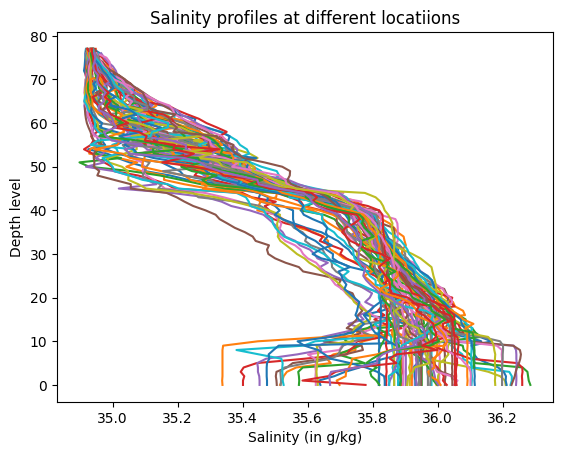

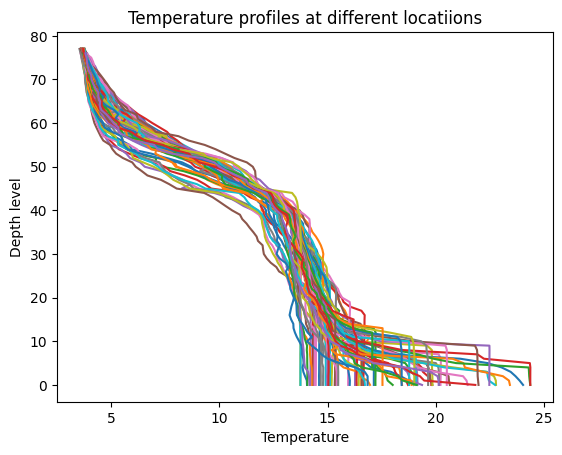

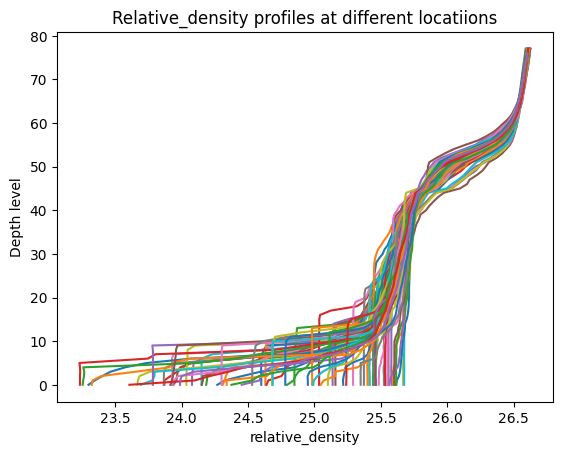

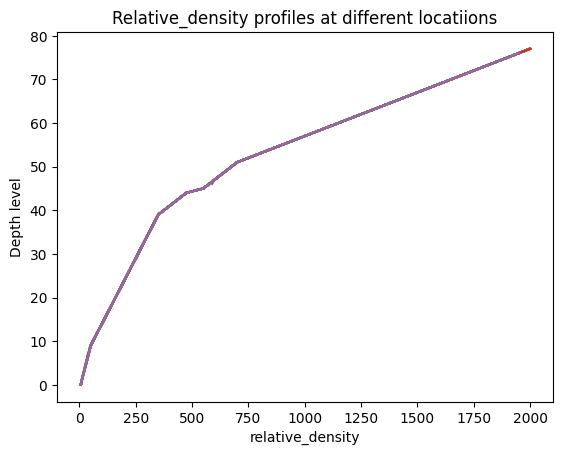

In [111]:
# Your solution here
# Hint: plt.figure() before each variable's plot, plt.show() after it
# Hint: plt.plot(S, level) draws one line per column of S
# Hint: the semicolon at the end of a plt.plot call suppresses the list of line objects
# Hint: plt.xlabel, plt.ylabel and plt.title each take a string

import matplotlib.pyplot as plt

plt.figure()
plt.plot(S, level)
plt.xlabel("Salinity (in g/kg)")
plt.ylabel("Depth level")
plt.title("Salinity profiles at different locatiions")
plt.show()

plt.figure()
plt.plot(T, level)
plt.xlabel("Temperature")
plt.ylabel("Depth level")
plt.title("Temperature profiles at different locatiions")
plt.show()

plt.figure()
plt.plot(relative_density, level)
plt.xlabel("relative_density")
plt.ylabel("Depth level")
plt.title("Relative_density profiles at different locatiions")
plt.show()

plt.figure()
plt.plot(P, level)
plt.xlabel("relative_density")
plt.ylabel("Depth level")
plt.title("Relative_density profiles at different locatiions")
plt.show()

**Step 10.** Now plot only the *mean* profile of each variable, with the standard deviation as
error bars.

Use the NaN-aware mean and standard deviation from Step 6, and draw them with `plt.errorbar`.
Because the variable is on the *x*-axis, the spread is a *horizontal* error bar — the keyword is
`xerr`, not `yerr`.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.3-target-argo-mean-profiles.png" alt="A single mean salinity profile against depth level with horizontal error bars at each level" width="500">

<em>The salinity panel again, reduced from 75 profiles to one line and its spread.</em>


In a comment, say what the width of the error bars tells you about how much the profiles disagree
near the surface compared with at depth.

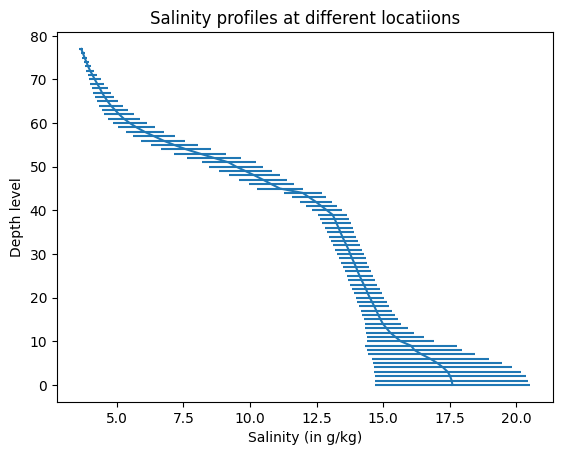

In [112]:
# Your solution here
# Hint: plt.errorbar(mean_S, level, xerr=std_S)
# Hint: use the nan-aware versions from Step 6, or every bar will be missing


plt.figure()
plt.errorbar(nanmean_T, level, xerr=nanstd_T)
plt.xlabel("Salinity (in g/kg)")
plt.ylabel("Depth level")
plt.title("Salinity profiles at different locatiions")
plt.show()

**Step 11.** Scatter the profiles' longitudes against their latitudes.

One point per profile. Label both axes and give it a title, and set the marker size with `s=` so
the points are readable. Then print the first three entries of `date` and the last one.

In a comment, say what the dates and the shape of the cloud tell you about how this set of
profiles was collected, and by how many floats.

In [22]:
# Your solution here
# Hint: plt.scatter(lon, lat)
# Hint: lon and lat have one entry per profile, not per level
# Hint: look at the spacing between consecutive dates



**ℹ️ What you just did**

You loaded a real oceanographic dataset, worked out its structure from the array shapes alone,
rebuilt a coordinate axis and verified it, evaluated a published equation of state as one
vectorised expression over 5,850 measurements (78 depth levels by 75 profiles), reduced along the
right axis, counted the missing values and switched to NaN-aware statistics, and saved a derived
product.

None of the computation needed a loop over the data. In the next subchapter `xarray` attaches the
names (depth, profile, latitude) to the axes you have been tracking by hand, and `matplotlib` gets
its full treatment, including the line, error-bar and scatter plots you drew here.